# EoR 21-cm Bispectrum Fisher analysis

Authors:
 
Leon Noble (phd2201121004@iiti.ac.in), IIT Indore

Yashrajsinh Mahida (phd2301121014@iiti.ac.in), IIT Indore

In [1]:
import numpy as np
import read_bs
import matplotlib.pyplot as plt
import corner
from matplotlib import colors

### Reading bispectrum data

In [2]:

# paths to the bs data
path_to_bs_data = "/home/leon/Documents/bs_fisher_inference_chapter/data/new_run/derivative/bs_data_out_new"
paths_params = [ "Lightcone_HII_EFF_FACTOR_400_Samples_Plus", "Lightcone_HII_EFF_FACTOR_400_Samples_Minus","Lightcone_ION_Tvir_MIN_400_Samples_Plus",
                "Lightcone_ION_Tvir_MIN_400_Samples_Minus", "Lightcone_R_BUBBLE_MAX_400_Samples_Plus", "Lightcone_R_BUBBLE_MAX_400_Samples_Minus"]
paths = [path_to_bs_data + "/" + path for path in paths_params]
bs_data_cov_path_ska_AA_star_1000 = "/home/leon/Documents/bs_fisher_inference_chapter/data/new_run/SKA_AA_star_1000/bs_data_out_new"
bs_data_cov_path_ska_AA_star_100 = "/home/leon/Documents/bs_fisher_inference_chapter/data/new_run/SKA_AA_star_100/bs_data_out_new"
bs_data_cov_path_ska_AA4_1000 = "/home/leon/Documents/bs_fisher_inference_chapter/data/new_run/SKA_AA4_1000/bs_data_out_new"


In [3]:
# arrays to hold the bispectrum data and related parameters
num_k1_values = 40  # number of k1 bins
num_samples = 399   # number of realizations
n_params = 3        # number of model parameters
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']  # parameter names

# bispectrum data for each parameter variation (plus/minus for each of 3 params)
data_bs_unique = np.zeros((6, num_samples, num_k1_values, 10, 10)) 

# fiducial bispectrum data for three different SKA configurations
data_bs_fidu_ska_AA_star_1000 = np.zeros((num_samples, num_k1_values, 10, 10)) 
data_bs_fidu_ska_AA_star_100 = np.zeros((num_samples, num_k1_values, 10, 10))
data_bs_fidu_ska_AA4_1000 = np.zeros((num_samples, num_k1_values, 10, 10))

# squeezed limit bispectrum data for each parameter variation and fiducial runs
data_bs_squeezed = np.zeros((6, num_samples, num_k1_values))
data_bs_fidu_ska_AA_star_1000_squeezed = np.zeros((num_samples, num_k1_values))
data_bs_fidu_ska_AA_star_100_squeezed = np.zeros((num_samples, num_k1_values))
data_bs_fidu_ska_AA4_1000_squeezed = np.zeros((num_samples, num_k1_values))

# Step sizes for finite difference derivatives of each parameter
delta_params = [
    10,  # HII_EFF_FACTOR
    10,  # R_BUBBLE_MAX
    pow(10, 4.740362689494244) - pow(10, 4.653212513775344)  # Tvir_MIN 
    ] 

In [4]:
# Reading bispectrum data for all unique triangles and the squeezed limit for all realizations

# loop over all parameters
for i in range(len(paths)):
    # loop over all realizations
    for j in range(num_samples):
        # Auto_BS_Data object for the current parameter and realization
        bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(paths[i], int(j)))
        k1_values, mu_bin, t_bin, data_bs_unique[i, j, :, :, :], ntri, bispec = bs_data.read_bispec_data()
        data_bs_squeezed[i, j, :] = bs_data.get_squeezed_limit()

# loop over all realizations for SKA AA star 1000 fiducial run
for j in range(num_samples):
    bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(bs_data_cov_path_ska_AA_star_1000, int(j)))
    k1_values, mu_bin, t_bin, data_bs_fidu_ska_AA_star_1000[j, :, :, :], ntri, bispec = bs_data.read_bispec_data()
    data_bs_fidu_ska_AA_star_1000_squeezed[j, :] = bs_data.get_squeezed_limit()

# loop over all realizations for SKA AA star 100 fiducial run
for j in range(num_samples):
    bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(bs_data_cov_path_ska_AA_star_100, int(j)))
    k1_values, mu_bin, t_bin, data_bs_fidu_ska_AA_star_100[j, :, :, :], ntri, bispec = bs_data.read_bispec_data()
    data_bs_fidu_ska_AA_star_100_squeezed[j, :] = bs_data.get_squeezed_limit()

# loop over all realizations for SKA AA4 1000 fiducial run
for j in range(num_samples):
    bs_data = read_bs.Auto_BS_Data("{}/realization_{}".format(bs_data_cov_path_ska_AA4_1000, int(j)))
    k1_values, mu_bin, t_bin, data_bs_fidu_ska_AA4_1000[j, :, :, :], ntri, bispec = bs_data.read_bispec_data()
    data_bs_fidu_ska_AA4_1000_squeezed[j, :] = bs_data.get_squeezed_limit()

In [5]:
# applying condition mu * t >= 0.50 to find all unique triangles (see arXiv:2001.10243)
index_list = []  # list to store indices of unique triangles
for i in range(len(mu_bin)):  # loop over all mu bins
    for j in range(len(t_bin)):  # loop over all t bins
        mu_t = mu_bin[i] * t_bin[j]  
        if mu_t >= 0.5:  # check the uniqueness condition
            index_list.append((i, j))  
index_list = np.array(index_list)  

# rearranging the bispectrum data for Fisher analysis (realizations, k1 values, unique triangles)
bs_data_unique_rearrange = np.zeros((6, 399, np.size(k1_values), np.shape(index_list)[0])) 
data_bs_fidu_ska_AA_star_1000_rearrange = np.zeros((num_samples, np.size(k1_values), np.shape(index_list)[0]))  
data_bs_fidu_ska_AA_star_100_rearrange = np.zeros((num_samples, np.size(k1_values), np.shape(index_list)[0]))  
data_bs_fidu_ska_AA4_1000_rearrange = np.zeros((num_samples, np.size(k1_values), np.shape(index_list)[0]))  
for i in range(np.shape(index_list)[0]):  
    bs_data_unique_rearrange[:, :, :, i] = data_bs_unique[:, :, :, index_list[i, 0], index_list[i, 1]] 
    data_bs_fidu_ska_AA_star_1000_rearrange[:, :, i] = data_bs_fidu_ska_AA_star_1000[:, :, index_list[i, 0], index_list[i, 1]]  
    data_bs_fidu_ska_AA_star_100_rearrange[:, :, i] = data_bs_fidu_ska_AA_star_100[:, :, index_list[i, 0], index_list[i, 1]] 
    data_bs_fidu_ska_AA4_1000_rearrange[:, :, i] = data_bs_fidu_ska_AA4_1000[:, :, index_list[i, 0], index_list[i, 1]]  

In [6]:
# finding derivatives for the bispectrum data for all unique triangles
der_bs_HII_EFF = bs_data_unique_rearrange[0, :, :, :] - bs_data_unique_rearrange[1, :, :, :] / delta_params[0]
der_bs_Tvir_MIN = bs_data_unique_rearrange[2, :, :, :] - bs_data_unique_rearrange[3, :, :, :] / delta_params[2]
der_bs_R_BUBBLE_MAX = bs_data_unique_rearrange[4, :, :, :] - bs_data_unique_rearrange[5, :, :, :] / delta_params[1]

In [7]:
sigma_unique_SKA_AA_star_1000 = np.zeros((num_k1_values, np.shape(index_list)[0]))
sigma_unique_SKA_AA_star_100 = np.zeros((num_k1_values, np.shape(index_list)[0]))
sigma_unique_SKA_AA4_1000 = np.zeros((num_k1_values, np.shape(index_list)[0]))
mask_unique_SKA_AA_star_1000 = np.zeros((num_k1_values, np.shape(index_list)[0]), dtype=bool)
mask_unique_SKA_AA_star_100 = np.zeros((num_k1_values, np.shape(index_list)[0]), dtype=bool)
mask_unique_SKA_AA4_1000 = np.zeros((num_k1_values, np.shape(index_list)[0]), dtype=bool)

for i in range(num_k1_values):
   mask_unique_SKA_AA_star_1000[i,:] = ~np.isnan(data_bs_fidu_ska_AA_star_1000_rearrange[:,i,:]).any(axis=0)
   sigma_unique_SKA_AA_star_1000[i, mask_unique_SKA_AA_star_1000[i,:]] = np.std(data_bs_fidu_ska_AA_star_1000_rearrange[:,i,mask_unique_SKA_AA_star_1000[i,:]], axis=0)
   mask_unique_SKA_AA_star_100[i,:] = ~np.isnan(data_bs_fidu_ska_AA_star_100_rearrange[:,i,:]).any(axis=0)
   sigma_unique_SKA_AA_star_100[i, mask_unique_SKA_AA_star_100[i,:]] = np.std(data_bs_fidu_ska_AA_star_100_rearrange[:,i,mask_unique_SKA_AA_star_100[i,:]], axis=0)
   mask_unique_SKA_AA4_1000[i,:] = ~np.isnan(data_bs_fidu_ska_AA4_1000_rearrange[:,i,:]).any(axis=0)
   sigma_unique_SKA_AA4_1000[i, mask_unique_SKA_AA4_1000[i,:]] = np.std(data_bs_fidu_ska_AA4_1000_rearrange[:,i,mask_unique_SKA_AA4_1000[i,:]], axis=0)



In [8]:
## Whitening step ##
cov_field_unique_SKA_AA_star_1000 = []
cov_field_unique_SKA_AA_star_100 = []
cov_field_unique_SKA_AA4_1000 = []


for j in range(num_k1_values):
    sliced_data_SKA_AA_Star_1000 = data_bs_fidu_ska_AA_star_1000_rearrange[:, j, :]  # slice for current k1
    maksed_data_SKA_AA_Star_1000 = sliced_data_SKA_AA_Star_1000[:, mask_unique_SKA_AA_star_1000[j]] # apply mask
    cov_field_temp_SKA_AA_Star_1000 = maksed_data_SKA_AA_Star_1000 / sigma_unique_SKA_AA_star_1000[j][mask_unique_SKA_AA_star_1000[j]]
    cov_field_unique_SKA_AA_star_1000.append(cov_field_temp_SKA_AA_Star_1000)

    sliced_data_SKA_AA_Star_100 = data_bs_fidu_ska_AA_star_100_rearrange[:, j, :]  # slice for current k1
    maksed_data_SKA_AA_Star_100 = sliced_data_SKA_AA_Star_100[:, mask_unique_SKA_AA_star_100[j]] # apply mask
    cov_field_temp_SKA_AA_Star_100 = maksed_data_SKA_AA_Star_100 / sigma_unique_SKA_AA_star_100[j][mask_unique_SKA_AA_star_100[j]]
    cov_field_unique_SKA_AA_star_100.append(cov_field_temp_SKA_AA_Star_100)

    sliced_data_SKA_AA4_1000 = data_bs_fidu_ska_AA4_1000_rearrange[:, j, :]  # slice for current k1
    maksed_data_SKA_AA4_1000 = sliced_data_SKA_AA4_1000[:, mask_unique_SKA_AA4_1000[j]] # apply mask
    cov_field_temp_SKA_AA4_1000 = maksed_data_SKA_AA4_1000 / sigma_unique_SKA_AA4_1000[j][mask_unique_SKA_AA4_1000[j]]
    cov_field_unique_SKA_AA4_1000.append(cov_field_temp_SKA_AA4_1000)


In [ ]:
# estimating the covariance for each k1
covariance_k1_SKA_AA_star_1000 = []
covariance_k1_SKA_AA_star_100 = []
covariance_k1_SKA_AA4_1000 = []

for j in range(num_k1_values):
    cov_temp = np.cov(cov_field_unique_SKA_AA_star_1000[j], rowvar=False)
    covariance_k1_SKA_AA_star_1000.append(cov_temp)

    cov_temp = np.cov(cov_field_unique_SKA_AA_star_100[j], rowvar=False)
    covariance_k1_SKA_AA_star_100.append(cov_temp)

    cov_temp = np.cov(cov_field_unique_SKA_AA4_1000[j], rowvar=False)
    covariance_k1_SKA_AA4_1000.append(cov_temp)
    
    print(f'log Condition number of the covariance matrix SKA AA* 1000: {np.log10(np.linalg.cond(covariance_k1_SKA_AA_star_1000[j])):.2f} (should be <= 7).')
    print(f'log Condition number of the covariance matrix SKA AA* 100: {np.log10(np.linalg.cond(covariance_k1_SKA_AA_star_100[j])):.2f} (should be <= 7).')
    print(f'log Condition number of the covariance matrix SKA AA4 1000: {np.log10(np.linalg.cond(covariance_k1_SKA_AA4_1000[j])):.2f} (should be <= 7).')

log Condition number of the covariance matrix SKA AA* 1000: 0.32 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 100: 0.22 (should be <= 7).
log Condition number of the covariance matrix SKA AA4 1000: 0.37 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 1000: 0.51 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 100: 0.29 (should be <= 7).
log Condition number of the covariance matrix SKA AA4 1000: 0.51 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 1000: 0.41 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 100: 0.29 (should be <= 7).
log Condition number of the covariance matrix SKA AA4 1000: 0.36 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 1000: 0.48 (should be <= 7).
log Condition number of the covariance matrix SKA AA* 100: 0.30 (should be <= 7).
log Condition number of the covariance matrix SKA AA4 1000: 0.39 (should be <= 7).
log Cond

In [ ]:
# Whitening the derivatives
deriv_field_unique_HII_EFF_SKA_AA_star_1000 = []
deriv_field_unique_Tvir_MIN_SKA_AA_star_1000 = []
deriv_field_unique_R_BUBBLE_MAX_SKA_AA_star_1000 = []

deriv_field_unique_HII_EFF_SKA_AA_star_100 = []
deriv_field_unique_Tvir_MIN_SKA_AA_star_100 = []
deriv_field_unique_R_BUBBLE_MAX_SKA_AA_star_100 = []

deriv_field_unique_HII_EFF_SKA_AA4_1000 = []
deriv_field_unique_Tvir_MIN_SKA_AA4_1000 = []
deriv_field_unique_R_BUBBLE_MAX_SKA_AA4_1000 = []

for j in range(num_k1_values):
    sliced__derv_field_HII_EFF = der_bs_HII_EFF[:, j, :]
    sliced__derv_field_Tvir_MIN = der_bs_Tvir_MIN[:, j, :]
    sliced__derv_field_R_BUBBLE_MAX = der_bs_R_BUBBLE_MAX[:, j, :]

    masksed_derv_field_HII_EFF_SKA_AA_star_1000 = sliced__derv_field_HII_EFF[:, mask_unique_SKA_AA_star_1000[j]]
    masksed_derv_field_Tvir_MIN_SKA_AA_star_1000 = sliced__derv_field_Tvir_MIN[:, mask_unique_SKA_AA_star_1000[j]] # apply mask
    masksed_derv_field_R_BUBBLE_MAX_SKA_AA_star_1000 = sliced__derv_field_R_BUBBLE_MAX[:, mask_unique_SKA_AA_star_1000[j]]

    masksed_derv_field_HII_EFF_SKA_AA_star_100 = sliced__derv_field_HII_EFF[:, mask_unique_SKA_AA_star_100[j]]
    masksed_derv_field_Tvir_MIN_SKA_AA_star_100 = sliced__derv_field_Tvir_MIN[:, mask_unique_SKA_AA_star_100[j]] # apply mask
    masksed_derv_field_R_BUBBLE_MAX_SKA_AA_star_100 = sliced__derv_field_R_BUBBLE_MAX[:, mask_unique_SKA_AA_star_100[j]] # apply mask

    masksed_derv_field_HII_EFF_SKA_AA4_1000 = sliced__derv_field_HII_EFF[:, mask_unique_SKA_AA4_1000[j]]
    masksed_derv_field_Tvir_MIN_SKA_AA4_1000 = sliced__derv_field_Tvir_MIN[:, mask_unique_SKA_AA4_1000[j]] # apply mask
    masksed_derv_field_R_BUBBLE_MAX_SKA_AA4_1000 = sliced__derv_field_R_BUBBLE_MAX[:, mask_unique_SKA_AA4_1000[j]] # apply mask

    deriv_field_unique_HII_EFF_SKA_AA_star_1000.append(masksed_derv_field_HII_EFF_SKA_AA_star_1000 / sigma_unique_SKA_AA_star_1000[j][mask_unique_SKA_AA_star_1000[j]])
    deriv_field_unique_Tvir_MIN_SKA_AA_star_1000.append(masksed_derv_field_Tvir_MIN_SKA_AA_star_1000 / sigma_unique_SKA_AA_star_1000[j][mask_unique_SKA_AA_star_1000[j]])
    deriv_field_unique_R_BUBBLE_MAX_SKA_AA_star_1000.append(masksed_derv_field_R_BUBBLE_MAX_SKA_AA_star_1000 / sigma_unique_SKA_AA_star_1000[j][mask_unique_SKA_AA_star_1000[j]])

    deriv_field_unique_HII_EFF_SKA_AA_star_100.append(masksed_derv_field_HII_EFF_SKA_AA_star_100 / sigma_unique_SKA_AA_star_100[j][mask_unique_SKA_AA_star_100[j]])
    deriv_field_unique_Tvir_MIN_SKA_AA_star_100.append(masksed_derv_field_Tvir_MIN_SKA_AA_star_100 / sigma_unique_SKA_AA_star_100[j][mask_unique_SKA_AA_star_100[j]])
    deriv_field_unique_R_BUBBLE_MAX_SKA_AA_star_100.append(masksed_derv_field_R_BUBBLE_MAX_SKA_AA_star_100 / sigma_unique_SKA_AA_star_100[j][mask_unique_SKA_AA_star_100[j]])

    deriv_field_unique_HII_EFF_SKA_AA4_1000.append(masksed_derv_field_HII_EFF_SKA_AA4_1000 / sigma_unique_SKA_AA4_1000[j][mask_unique_SKA_AA4_1000[j]])
    deriv_field_unique_Tvir_MIN_SKA_AA4_1000.append(masksed_derv_field_Tvir_MIN_SKA_AA4_1000 / sigma_unique_SKA_AA4_1000[j][mask_unique_SKA_AA4_1000[j]])
    deriv_field_unique_R_BUBBLE_MAX_SKA_AA4_1000.append(masksed_derv_field_R_BUBBLE_MAX_SKA_AA4_1000 / sigma_unique_SKA_AA4_1000[j][mask_unique_SKA_AA4_1000[j]])

In [ ]:
samples = np.arange(5, num_samples+5, 5)
BS_Fisher_SKA_AA_star_1000 = np.zeros((num_k1_values,samples.shape[0], n_params, n_params))
BS_Fisher_SKA_AA_star_100 = np.zeros((num_k1_values,samples.shape[0], n_params, n_params))
BS_Fisher_SKA_AA4_1000 = np.zeros((num_k1_values,samples.shape[0], n_params, n_params))

for i in range(num_k1_values):
    # SKA AA star 1000
    deriv_field_specific_config_SKA_AA_star_1000 = np.zeros((n_params, num_samples, np.shape(deriv_field_unique_HII_EFF_SKA_AA_star_1000[i])[-1]))
    deriv_field_specific_config_SKA_AA_star_1000[0, :, :] = deriv_field_unique_Tvir_MIN_SKA_AA_star_1000[i]
    deriv_field_specific_config_SKA_AA_star_1000[1, :, :] = deriv_field_unique_R_BUBBLE_MAX_SKA_AA_star_1000[i]
    deriv_field_specific_config_SKA_AA_star_1000[2, :, :] = deriv_field_unique_HII_EFF_SKA_AA_star_1000[i]
    covariance_specific_SKA_AA_star_1000 = covariance_k1_SKA_AA_star_1000[i]

    # SKA AA star 100
    deriv_field_specific_config_SKA_AA_star_100 = np.zeros((n_params, num_samples, np.shape(deriv_field_unique_HII_EFF_SKA_AA_star_100[i])[-1]))
    deriv_field_specific_config_SKA_AA_star_100[0, :, :] = deriv_field_unique_Tvir_MIN_SKA_AA_star_100[i]
    deriv_field_specific_config_SKA_AA_star_100[1, :, :] = deriv_field_unique_R_BUBBLE_MAX_SKA_AA_star_100[i]
    deriv_field_specific_config_SKA_AA_star_100[2, :, :] = deriv_field_unique_HII_EFF_SKA_AA_star_100[i]
    covariance_specific_SKA_AA_star_100 = covariance_k1_SKA_AA_star_100[i]

    # SKA AA4 1000
    deriv_field_specific_config_SKA_AA4_1000 = np.zeros((n_params, num_samples, np.shape(deriv_field_unique_HII_EFF_SKA_AA4_1000[i])[-1]))
    deriv_field_specific_config_SKA_AA4_1000[0, :, :] = deriv_field_unique_Tvir_MIN_SKA_AA4_1000[i]
    deriv_field_specific_config_SKA_AA4_1000[1, :, :] = deriv_field_unique_R_BUBBLE_MAX_SKA_AA4_1000[i]
    deriv_field_specific_config_SKA_AA4_1000[2, :, :] = deriv_field_unique_HII_EFF_SKA_AA4_1000[i]
    covariance_specific_SKA_AA4_1000 = covariance_k1_SKA_AA4_1000[i]

    for k, sample in enumerate(samples):
        deriv_sample_specific_SKA_AA_star_1000 = np.mean(deriv_field_specific_config_SKA_AA_star_1000[:, :sample, :], axis=1)
        deriv_sample_specific_SKA_AA_star_100 = np.mean(deriv_field_specific_config_SKA_AA_star_100[:, :sample, :], axis=1)
        deriv_sample_specific_SKA_AA4_1000 = np.mean(deriv_field_specific_config_SKA_AA4_1000[:, :sample, :], axis=1)
        for j in range(n_params):
            for l in range(n_params):
                BS_Fisher_SKA_AA_star_1000[i, k, j, l] = np.dot(deriv_sample_specific_SKA_AA_star_1000[j], np.dot(np.linalg.inv(covariance_specific_SKA_AA_star_1000), deriv_sample_specific_SKA_AA_star_1000[l]))
                BS_Fisher_SKA_AA_star_100[i, k, j, l] = np.dot(deriv_sample_specific_SKA_AA_star_100[j], np.dot(np.linalg.inv(covariance_specific_SKA_AA_star_100), deriv_sample_specific_SKA_AA_star_100[l]))
                BS_Fisher_SKA_AA4_1000[i, k, j, l] = np.dot(deriv_sample_specific_SKA_AA4_1000[j], np.dot(np.linalg.inv(covariance_specific_SKA_AA4_1000), deriv_sample_specific_SKA_AA4_1000[l]))

            

In [ ]:
BS_Fisher_k1_SKA_AA_star_1000 =  np.sum(BS_Fisher_SKA_AA_star_1000, axis=0)
BS_Fisher_k1_SKA_AA_star_100 =  np.sum(BS_Fisher_SKA_AA_star_100, axis=0)
BS_Fisher_k1_SKA_AA4_1000 =  np.sum(BS_Fisher_SKA_AA4_1000, axis=0)

BS_Fisher_INV_SKA_AA_star_1000 = np.zeros((samples.shape[0], n_params, n_params))
BS_Fisher_INV_SKA_AA_star_100 = np.zeros((samples.shape[0], n_params, n_params))
BS_Fisher_INV_SKA_AA4_1000 = np.zeros((samples.shape[0], n_params, n_params))


for i, sample in enumerate(samples):
    BS_Fisher_INV_SKA_AA_star_1000[i] = np.linalg.inv(BS_Fisher_k1_SKA_AA_star_1000[i])
    BS_Fisher_INV_SKA_AA_star_100[i] = np.linalg.inv(BS_Fisher_k1_SKA_AA_star_100[i])
    BS_Fisher_INV_SKA_AA4_1000[i] = np.linalg.inv(BS_Fisher_k1_SKA_AA4_1000[i])


Text(0.5, 1.0, 'Convergence of the Fisher inverse matrix diagonal elements')

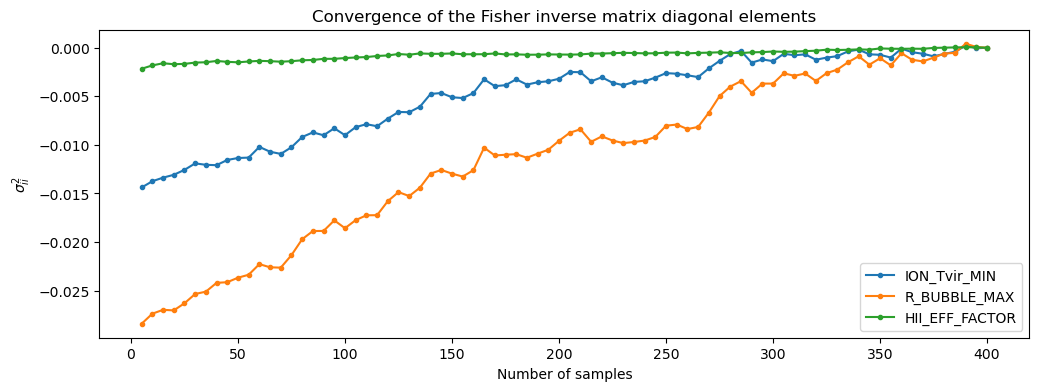

In [192]:
# SKA AA star 1000
plt.figure(figsize=(12, 4))
for i, param in enumerate(params):
    plt.plot(samples, [np.diag(BS_Fisher_INV_SKA_AA_star_1000[k])[i]-np.diag(BS_Fisher_INV_SKA_AA_star_1000[-1])[i] for k in range(samples.size)], marker='.', label=param)
plt.legend()
plt.ylabel(r'$\sigma^2_{ii}$')
plt.xlabel('Number of samples')
plt.title('Convergence of the Fisher inverse matrix diagonal elements')

Text(0.5, 1.0, 'Convergence of the Fisher inverse matrix diagonal elements')

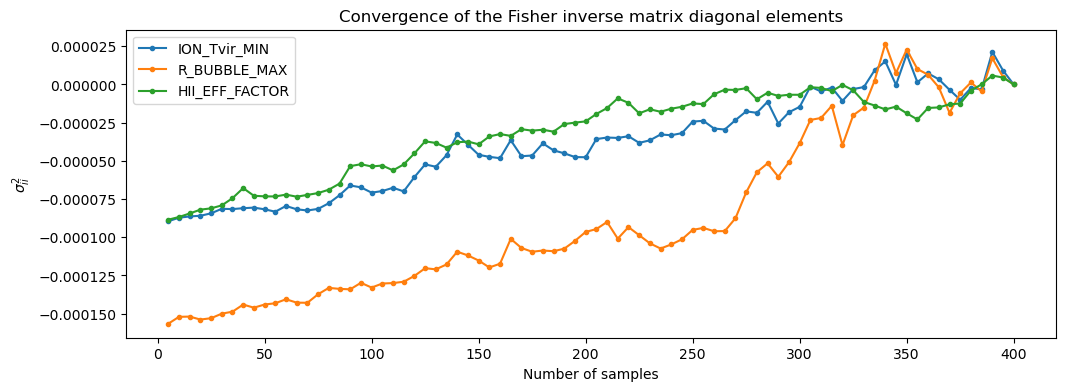

In [207]:
# SKA AA4 1000
plt.figure(figsize=(12, 4))
for i, param in enumerate(params):
    plt.plot(samples, [np.diag(BS_Fisher_INV_SKA_AA4_1000[k])[i]-np.diag(BS_Fisher_INV_SKA_AA4_1000[-1])[i] for k in range(samples.size)], marker='.', label=param)
plt.legend()
plt.ylabel(r'$\sigma^2_{ii}$')
plt.xlabel('Number of samples')
plt.title('Convergence of the Fisher inverse matrix diagonal elements')

Text(0.5, 1.0, 'Convergence of the Fisher inverse matrix diagonal elements')

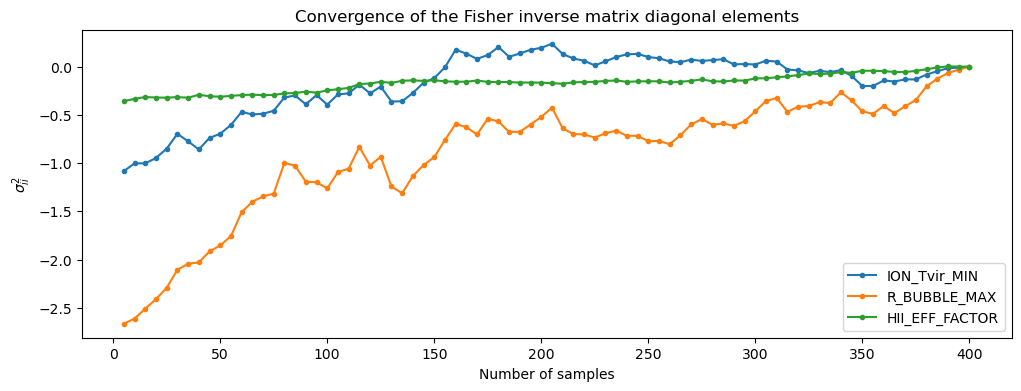

In [208]:
# SKA AA star 100
plt.figure(figsize=(12, 4))
for i, param in enumerate(params):
    plt.plot(samples, [np.diag(BS_Fisher_INV_SKA_AA_star_100[k])[i]-np.diag(BS_Fisher_INV_SKA_AA_star_100[-1])[i] for k in range(samples.size)], marker='.', label=param)
plt.legend()
plt.ylabel(r'$\sigma^2_{ii}$')
plt.xlabel('Number of samples')
plt.title('Convergence of the Fisher inverse matrix diagonal elements')

In [209]:

fid = [50118.72336272725,15,30]
fisher_data_SKA_AA_star_1000 = np.random.multivariate_normal(fid, BS_Fisher_INV_SKA_AA_star_1000[-1], size=50000)
fisher_data_SKA_AA_star_100 = np.random.multivariate_normal(fid, BS_Fisher_INV_SKA_AA_star_100[-1], size=50000)
fisher_data_SKA_AA4_1000 = np.random.multivariate_normal(fid, BS_Fisher_INV_SKA_AA4_1000[-1], size=50000)
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']

In [196]:
Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']

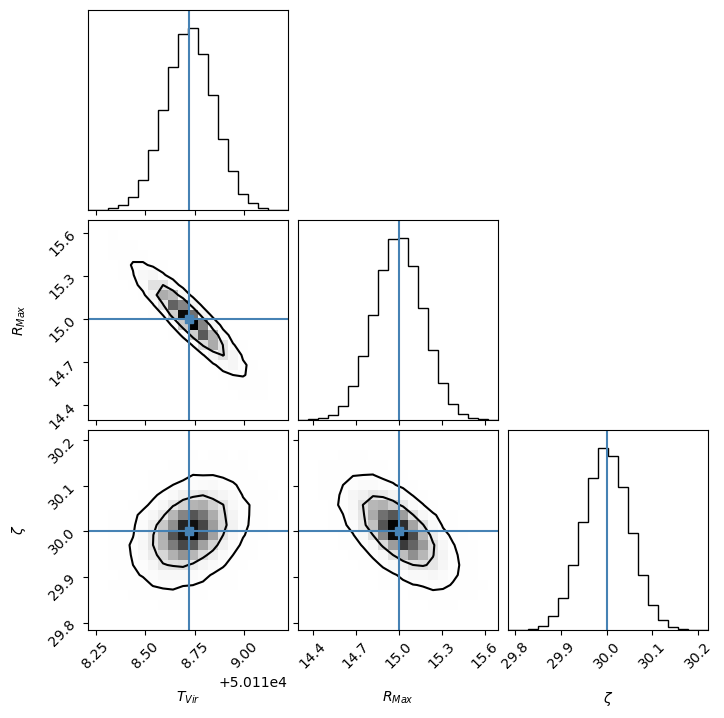

In [210]:
_= corner.corner(
    fisher_data_SKA_AA_star_1000,
    labels=Fisher_Param,
    plot_datapoints=False,  
    levels=(0.68,0.95),
    truths=fid)

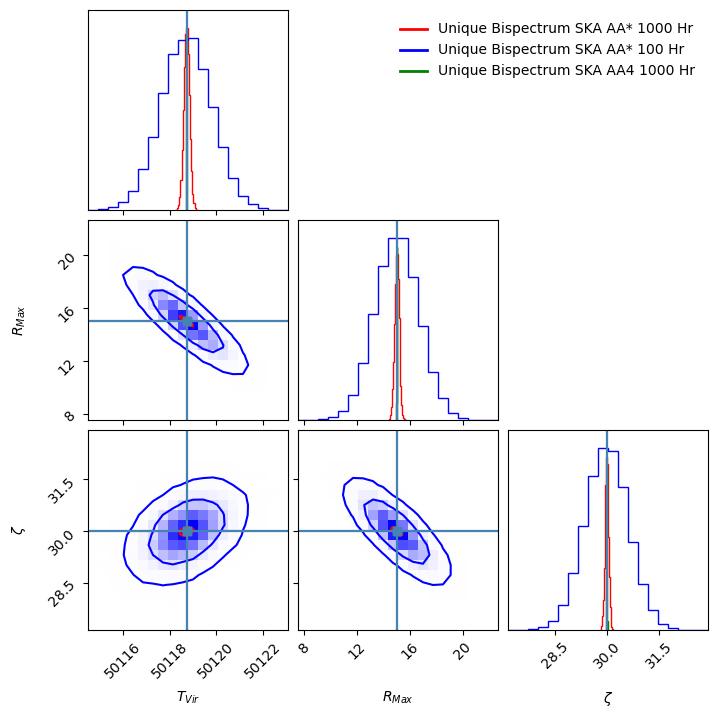

In [211]:

datasets = [fisher_data_SKA_AA_star_1000, fisher_data_SKA_AA_star_100, fisher_data_SKA_AA4_1000]
dataset_labels = ["Unique Bispectrum SKA AA* 1000 Hr", "Unique Bispectrum SKA AA* 100 Hr", "Unique Bispectrum SKA AA4 1000 Hr"]
colors = ["r", "b", "g"]  
labels = Fisher_Param
truths = fid

fig = corner.corner(
    datasets[0],
    labels=labels,
    plot_datapoints=False,
    levels=(0.68, 0.95),
    color=colors[0],
    truths=truths,
)
for i in range(1, len(datasets)):
    corner.corner(
        datasets[i],
        labels=labels,
        plot_datapoints=False,
        levels=(0.68, 0.95),
        color=colors[i],
        truths=truths,
        fig=fig,  
    )

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=colors[i], lw=2, label=dataset_labels[i])
    for i in range(len(datasets))
]

axes = np.array(fig.axes).reshape((len(labels), len(labels)))
ax = axes[0, -1]  
ax.legend(handles=legend_handles, loc='upper right', frameon=False)
